# Discord moderation triage

**Recipe 16** · Level 2 (Easy) · Decision type: `Choice`

Classify sample Discord messages as allowed, review-needed, or potentially violating a supplied community rule to populate a simulated moderator queue.

Sources:

- S02: [TypeSafe AI: Primitives (Questions)](https://docs.typesafe.ai/primitives)
- S03: [TypeSafe AI: Confidence](https://docs.typesafe.ai/confidence)
- S04: [TypeSafe AI: How to build with TypeSafe](https://docs.typesafe.ai/concepts/how-to-build-with-system-one)
- S07: [TypeSafe AI: Jev 1.13 jaggedness](https://docs.typesafe.ai/model-jaggedness/jev-1.13)

## What you will build

A small moderation triage tool for a fabricated Discord server. Jev reads one message, together with the server's own community rule, and picks exactly one of three fixed categories: `allowed`, `review_needed` (the explicit outcome for a message whose tone or context a reader cannot be sure of), or `potentially_violating`. Python owns everything else: the state Jev sees, the identifiers that never reach the model, and a rule that turns the category and its confidence into one of four simulated moderation actions -- `ignore`, `warn`, `hide`, or `escalate` to a person -- through `jev_cookbook.simulation`'s `ActionLog` and `ReviewQueue`. Nothing here posts, deletes, or sends anything to a real server. By the end you will have looked at individual typed answers across the hard cases this use case names -- sarcasm, a message that only quotes or reports someone else's abusive words, borderline banter, and a benign message that merely contains a word the rule's examples mention -- seen the rule that turns them into simulated actions, and run an evaluation over 40 synthetic messages (19 `validation`, 19 `test`, 2 `demo`) that reports a confusion matrix, the separate cost of a false allow against a false flag, and the coverage, accuracy and risk the rule's own outcomes produce.


## Setup and run mode

The notebook runs from its own folder with the standard library and `jev_cookbook` only. `get_backend(fixtures=...)` replays the 40 stored answers in `fixtures/responses.json` offline; setting `JEV_COOKBOOK_LIVE=1` (see the README) swaps in live calls to the same question definition and changes nothing else. `run_header` states which [run mode](../../docs/glossary.md#run-mode) ran, and every number below carries that mode with it.


In [1]:
from jev_cookbook import get_backend, load_helpers
from jev_cookbook.evaluation import (
    confusion_matrix,
    evaluate_outcomes,
    per_class_metrics,
    select_confidence_threshold,
)
from jev_cookbook.fixtures import load_inputs, load_labels, responses_path, select_split
from jev_cookbook.simulation import ActionLog, ReviewQueue
from jev_cookbook.style import (
    apply_style,
    plot_answer_probabilities,
    plot_confusion_matrix,
    run_header,
    show_answer,
)

apply_style()
helpers = load_helpers()  # this recipe's helpers.py, loaded by path
examples = load_inputs()
labels = load_labels()  # {id: gold label}, one per validation/test example
backend = get_backend(fixtures=responses_path())
questions = helpers.build_questions()
# N for the header is the number of examples the metrics are about: validation and test. This
# recipe has no train split; demo examples are shown but never scored.
scored = [e for e in examples if e.split not in ("train", "demo")]

offline = backend.mode in ("synthetic", "scripted")
check = " (a pipeline check, not a Jev result)" if offline else ""
# CONTRIBUTING.md section 2: "a number from the validation split is a selection step, not a
# result." This label does not depend on the run mode, unlike `check` above: even a recorded or
# live run must not print a bare validation number.
selection = " (a selection step, not a reported result)"

# Every one of the 40 examples in fixtures/ needs at most one request. This cache makes sure a
# message that is shown individually and later scored in its split is decided once, so the
# whole notebook makes exactly 40 requests in live mode, never more.
answered = {}


def decide(example):
    if example.id not in answered:
        answered[example.id] = backend.decide(helpers.build_state(example.fields), questions)[
            "triage"
        ]
    return answered[example.id]


run_header(
    16,
    "Discord moderation triage",
    backend=backend,
    n_examples=len(scored),
)

Recipe 16: Discord moderation triage
Mode: offline replay of synthetic fixtures, pipeline check on a fixture sample of 38 examples
Metrics in this run are checks that the pipeline works. They are not Jev results.


## The state

The [state](../../docs/glossary.md#state) is everything Jev sees, and Python builds it. Every message in this recipe is checked against the same community rule, `helpers.RULE_TEXT`, so `build_state` attaches it to every request alongside the message text. Each example in `fixtures/inputs.jsonl` also carries a `message_id` and an `author`; Python keeps both to itself and attaches them to the outcome at the end, so an identifier never passes through the model and every result still traces back to its message.


In [2]:
import json

demo = {e.id: e for e in examples if e.split == "demo"}
example = demo["d01-trigger-word"]
print("Python has:")
print(json.dumps(example.fields, indent=2))
state = helpers.build_state(example.fields)
print("Jev sees:")
print(json.dumps(state, indent=2))

Python has:
{
  "message_id": "MSG-7001",
  "author": "nova_badger",
  "message": "I'm going to kill this raid boss tonight if it's the last thing I do, let's go"
}
Jev sees:
{
  "rule": "Lumen Games Community conduct rule: be respectful. Do not harass, threaten, demean, or target a member for who they are. No hate speech, no threats of violence or self-harm, and no sharing someone else's private information. Friendly joking between members who both enjoy it is fine; it stops being fine the moment it singles someone out or makes them a target.",
  "message": "I'm going to kill this raid boss tonight if it's the last thing I do, let's go"
}


## The questions

There is one question, and it asks one thing: given the rule above, which of three categories does the message belong to? A [`Choice`](../../docs/glossary.md#choice) fits because the categories are exclusive and Jev should commit to one ([S02](https://docs.typesafe.ai/primitives) describes `Choice` as picking exactly one option from a fixed, known set with no order between them; the option set here is built by Python, not invented by the model). `allowed` and `potentially_violating` are the two outcomes the use case names directly; `review_needed` is the explicit uncertain outcome Level 2 scope asks for, for a message whose tone or context a reader cannot be sure of -- not a confidence artifact Python adds on top, but a category the question itself offers on equal footing with the other two. The two flagged categories' descriptions say what belongs to the other instead, for the pair that is easiest to confuse: a message that quotes or reports someone else's abusive words belongs to `review_needed`, not `potentially_violating`, even when the quoted words are harsh ([S07](https://docs.typesafe.ai/model-jaggedness/jev-1.13) item 6, "adversarial content": the documentation says Jev does not treat the state as hostile by default, so a message that only *carries* hostile words can read as hostile itself unless told otherwise). The instructions ask about the rule directly rather than leaving it implicit, because [S07](https://docs.typesafe.ai/model-jaggedness/jev-1.13) item 8 notes a lean toward whichever option comes first in a close call; the options below are listed in a fixed order (`allowed`, `review_needed`, `potentially_violating`) for every message, so that bias, if present, affects every message the same way rather than depending on how a particular recipe happened to order them.

A `Choice` answer's [`confidence`](../../docs/glossary.md#confidence) is the top probability rescaled by the number of options, `(p_max - 1/n) / (1 - 1/n)` ([S03](https://docs.typesafe.ai/confidence)): with three options, 0 when the top option holds no more than a third of the probability, 1 when one option holds all of it. A low confidence does not mean a message is unreadable; it means the top category did not pull far ahead of an even third, which is often the honest shape for a genuinely ambiguous message's probabilities to take.


In [3]:
triage = questions["triage"]
print(triage.instructions)
print()
for name, description in triage.criteria.items():
    print(f"{name}:")
    print(f"  {description}")
    print()

Given the community rule above, which of these three categories does the message belong to?

allowed:
  The message does not violate the rule above. This includes a message that merely uses a word the rule's examples mention (for instance 'kill', 'die', 'hate') in a way that plainly has nothing to do with a person: a game, a sport, or ordinary hyperbole. It also includes friendly joking between members that does not single anyone out, and a heated but respectful disagreement.

review_needed:
  The message does not clearly fit allowed or potentially_violating: its tone depends on context a reader cannot be sure of (sarcasm that could be read either way, banter that might or might not be welcome to the person on the other end, a vague message that could be about someone specific), or it quotes or describes someone else's abusive words -- for example reporting what another member said -- rather than being abusive in its own words. A person should look at it.

potentially_violating:
  The 

## One answer up close

Before any aggregate number, look at three typed answers that cover this recipe's hard cases: a benign message that merely contains a word the rule's examples mention, a message that reports someone else's abusive words rather than being abusive itself, and one this recipe's stored answer gets wrong. Each answer holds the chosen category, a probability for every category, the `confidence` explained above, and a [`provenance`](../../docs/glossary.md#provenance) line that says where the answer came from, here always `synthetic`, since nothing in this recipe's fixtures came from a real call.


I'm going to kill this raid boss tonight if it's the last thing I do, let's go
Choice: allowed (confidence 0.77)
  allowed                0.85  #################
  review_needed          0.10  ##
  potentially_violating  0.05  #
Provenance: synthetic


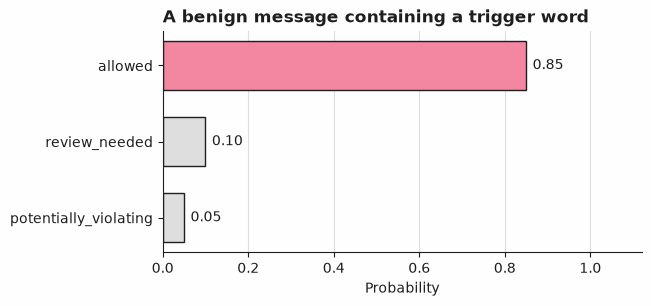

In [4]:
trigger_example = demo["d01-trigger-word"]
trigger_answer = decide(trigger_example)
print(trigger_example.fields["message"])
show_answer(trigger_answer)
plot_answer_probabilities(trigger_answer, title="A benign message containing a trigger word")

"I'm going to kill this raid boss tonight" uses a word the rule's examples mention ("threats of violence"), but the target is a video game boss, not a person: the message is harmless, and this fixture's stored answer puts `allowed` clearly ahead at 0.85 (`confidence` 0.775, `(0.85 - 1/3) / (1 - 1/3)`). This is the context-sensitive matching Level 2 scope asks for: a rule that only checked for the word "kill" would flag this message for nothing.


In [5]:
quoted_example = demo["d02-quoted-report"]
quoted_answer = decide(quoted_example)
print(quoted_example.fields["message"])
show_answer(quoted_answer)

can someone check this? misty_falcon told me 'you're an idiot and should just leave' in dms
Choice: review_needed (confidence 0.62)
  review_needed          0.75  ###############
  potentially_violating  0.15  ###
  allowed                0.10  ##
Provenance: synthetic


This message reports what someone else said; its own words ask a moderator to look at that, and do not themselves harass anyone. This fixture's stored answer correctly leans toward `review_needed` at 0.75 (`confidence` 0.6250), not `potentially_violating`: a person should still look at it, because the words it quotes are harsh and Python cannot verify from the message alone that the quote is accurate or complete, but the message itself is not the violation.


In [6]:
wrong_example = next(e for e in examples if e.id == "v07-quoted-abuse")
wrong_answer = decide(wrong_example)
print(wrong_example.fields["message"])
show_answer(wrong_answer)

can a mod look at this? dax told me 'nobody wants you here, just quit already' in general chat yesterday
Choice: potentially_violating (confidence 0.67)
  potentially_violating  0.78  ################
  review_needed          0.17  ###
  allowed                0.05  #
Provenance: synthetic


This message is the same shape as the one above -- reporting someone else's abusive words -- and its [gold label](../../docs/glossary.md#gold-label) (the correct category this recipe's fixtures record for evaluation, decided in advance by the rule each option's description states, never by Jev) is also `review_needed`. This fixture's stored answer gets it wrong, confidently: `potentially_violating` at 0.78 (`confidence` 0.6700). This is the adversarial-content risk named above: the quoted words ("nobody wants you here, just quit already") are themselves hostile, and a literal reading of the message's content, without weighing that those words are attributed to someone else, mistakes the report for the violation in this stored answer. The evaluation below shows what Python's rule does about this exact kind of mistake, and what it does not catch.


## Python's part

Jev supplies the category; what happens next is code. `helpers.moderate` turns a category and its confidence into one of four simulated actions: `ignore` for `allowed`, which has no side effect and is therefore final whatever the confidence (CONTRIBUTING.md section 4: a low-confidence fallback-shaped option may be a final result, without going through review, exactly when it has no side effect); `warn` or `hide` for a confident `review_needed` or `potentially_violating`; and `escalate` -- to a simulated human moderator -- for anything flagged whose confidence does not clear what this cookbook calls the **confidence gate**, or for an option outside the fixed set (a defensive check, since the backend already rejects a foreign option on its own). `tests/test_helpers.py` checks every branch of this rule for every label, so the claim "it holds whatever the model answers" is checked, not asserted.

The confidence gate itself is chosen here, on `validation`, and then frozen for the rest of this notebook. Only a flagged category (`review_needed` or `potentially_violating`) is ever gated on confidence -- `allowed` never is -- so the gate is selected from exactly that gated subset of `validation`: `select_confidence_threshold` picks the lowest confidence whose gated answers are all correct, which is as much automatic coverage as this fixture set allows without accepting a wrong answer *on validation*. Applying that frozen gate to the three answers shown above, plus a confidently `potentially_violating` message and a confidently `review_needed` one for contrast, demonstrates every action the rule can produce.


In [7]:
val_examples = select_split(examples, "validation")
val_answers = [decide(e) for e in val_examples]
val_gold = [labels[e.id] for e in val_examples]

# Only a flagged category is ever gated on confidence (`allowed` always resolves to `ignore`),
# so only the gated subset of validation can set the bar: reusing every validation answer here,
# `allowed` ones included, would let messages the rule never gates set a threshold for messages
# it does.
gated = [
    (a.choice == g, a.confidence)
    for a, g in zip(val_answers, val_gold, strict=True)
    if a.choice != helpers.ALLOWED
]
threshold = select_confidence_threshold(
    [ok for ok, _ in gated], [c for _, c in gated], target_accuracy=1.0
)
print(f"flagged validation answers: {len(gated)} of {len(val_answers)}{selection}{check}")
print(f"chosen confidence gate, frozen from here on: {threshold:.4f}{selection}{check}")

violating_example = next(e for e in val_examples if e.id == "v04-violating-insult")
violating_answer = decide(violating_example)
sarcasm_example = next(e for e in val_examples if e.id == "v06-sarcasm")
sarcasm_answer = decide(sarcasm_example)
for shown_example, shown_answer in (
    (trigger_example, trigger_answer),
    (quoted_example, quoted_answer),
    (wrong_example, wrong_answer),
    (violating_example, violating_answer),
    (sarcasm_example, sarcasm_answer),
):
    result = helpers.moderate(shown_example.fields["message_id"], shown_answer, threshold)
    print(
        f"{result.message_id}: {shown_answer.choice} at confidence {shown_answer.confidence:.4f} "
        f"-> {result.action} ({result.reason})"
    )

flagged validation answers: 12 of 19 (a selection step, not a reported result) (a pipeline check, not a Jev result)
chosen confidence gate, frozen from here on: 0.7600 (a selection step, not a reported result) (a pipeline check, not a Jev result)
MSG-7001: allowed at confidence 0.7750 -> ignore (allowed: no action, whatever the confidence)
MSG-7002: review_needed at confidence 0.6250 -> escalate (confidence below the threshold)
MSG-5007: potentially_violating at confidence 0.6700 -> escalate (confidence below the threshold)
MSG-5004: potentially_violating at confidence 0.8500 -> hide (confident potentially_violating: hide)
MSG-5006: review_needed at confidence 0.8050 -> warn (confident review_needed: warn, do not hide)


## Simulating the moderator queue

Issue #16 asks for more than a printed decision: `warn`-ed and `hide`-den messages are simulated actions, and anything escalated is supposed to land in a simulated moderator queue. `jev_cookbook.simulation.ActionLog` and `ReviewQueue` are the shared primitives for exactly this: `ActionLog.record` keeps a note that an action was *decided*, never executed (`executed` is always `False`), and `ReviewQueue.submit` keeps an escalated item, the reason it was sent, and the typed answer behind that reason, so a later cell can show why. The two `demo` messages shown above are illustrations, not scored traffic, so they never reach either one; this cell seeds both with every `validation` message instead (the 2 demo examples are the only ones left out). The "Evaluation" section below adds `test`'s messages to the same log and queue, so the queue grows exactly the way one would over two batches of real traffic.


In [8]:
action_log = ActionLog()
review_queue = ReviewQueue()


def act(example, answer, threshold):
    result = helpers.moderate(example.fields["message_id"], answer, threshold)
    item = {"message_id": result.message_id, "author": example.fields["author"]}
    if result.action == helpers.ESCALATE:
        review_queue.submit(item, result.reason, answer=answer)
    else:
        action_log.record(result.action, item, answer=answer, rule="helpers.moderate")
    return result


val_results = [act(e, a, threshold) for e, a in zip(val_examples, val_answers, strict=True)]
print(f"action log after validation: {len(action_log)} entries{selection}{check}")
print(f"review queue after validation: {len(review_queue)} items{selection}{check}")
for item in review_queue.to_dicts():
    print(f"  {item['item']['message_id']}: {item['reason']}")

action log after validation: 13 entries (a selection step, not a reported result) (a pipeline check, not a Jev result)
review queue after validation: 6 items (a selection step, not a reported result) (a pipeline check, not a Jev result)
  MSG-5007: confidence below the threshold
  MSG-5008: confidence below the threshold
  MSG-5012: confidence below the threshold
  MSG-5015: confidence below the threshold
  MSG-5018: confidence below the threshold
  MSG-5019: confidence below the threshold


## Evaluation

The confidence gate was chosen and frozen above, on `validation`. This section reports what the frozen rule does: `helpers.moderate` is applied to every example in `validation` and in `test` (via the same `act` function the queue above uses, never a separate reimplementation), and every number below comes from what it actually returned. Alongside that, `jev_cookbook.evaluation` reports a confusion matrix of the raw category against the gold label, and the cost of a false allow -- a message that should have been flagged but was called `allowed` -- discussed separately from a false flag -- an allowed message that was wrongly flagged. In an offline run every `test` number here is a check that the pipeline works, and it says so; every `validation` number, in every run mode, is a selection step rather than a reported result, which is why it carries both labels.


test, 19 examples, confidence gate 0.7600 frozen (a pipeline check, not a Jev result)
accuracy of the raw category: 0.8421 (a pipeline check, not a Jev result)


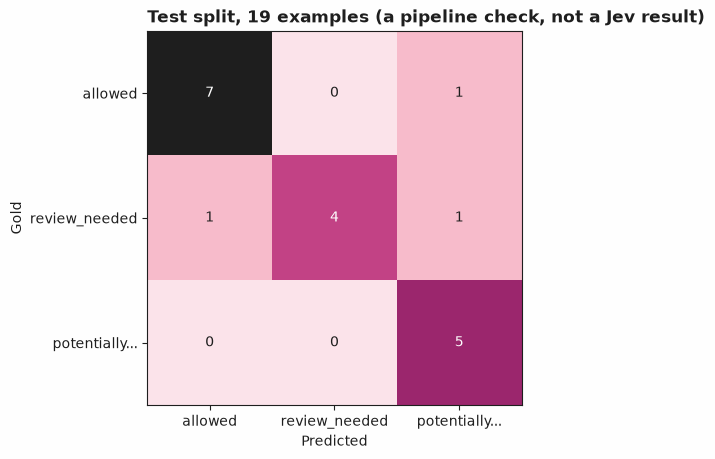

In [9]:
test_examples = select_split(examples, "test")
test_answers = [decide(e) for e in test_examples]
test_gold = [labels[e.id] for e in test_examples]

raw_accuracy = sum(a.choice == g for a, g in zip(test_answers, test_gold, strict=True)) / len(
    test_examples
)
print(f"test, {len(test_examples)} examples, confidence gate {threshold:.4f} frozen{check}")
print(f"accuracy of the raw category: {raw_accuracy:.4f}{check}")

matrix = confusion_matrix(test_gold, test_answers, labels=list(helpers.OPTIONS))
plot_confusion_matrix(matrix, title=f"Test split, {len(test_examples)} examples{check}")

A **false allow** is a message that should have been flagged (`review_needed` or `potentially_violating`) but was called `allowed`: nothing happens to it, and -- because `allowed` never passes through the confidence gate -- no later step catches the mistake either. A **false flag** is the opposite: an actually `allowed` message wrongly called `review_needed` or `potentially_violating`, which costs at least a person's attention (`escalate`) and, if the wrong answer is also confident, a wrongly hidden message (`hide`). The two costs are not symmetric: a false allow is invisible once it happens, while a false flag is visible and, even at its worst, reversible by a person looking at the queue or the log. `precision` below is the fraction of the rule's `allowed` calls that were actually right, and `recall` is the fraction of the truly-`allowed` messages the rule actually caught; a false allow costs `allowed`'s precision, and a false flag costs its recall.


In [10]:
per_class = per_class_metrics(test_gold, test_answers, labels=list(helpers.OPTIONS))
for label, counts in per_class.items():
    print(
        f"{label:22s} precision {counts.precision:.4f}  recall {counts.recall:.4f}  "
        f"f1 {counts.f1:.4f}  support {counts.support}{check}"
    )

false_allow = [
    e.id
    for e, a, g in zip(test_examples, test_answers, test_gold, strict=True)
    if a.choice == helpers.ALLOWED and g != helpers.ALLOWED
]
false_flag = [
    e.id
    for e, a, g in zip(test_examples, test_answers, test_gold, strict=True)
    if a.choice != helpers.ALLOWED and g == helpers.ALLOWED
]
print(f"false allow (flagged message called allowed): {false_allow}{check}")
print(f"false flag (allowed message called flagged): {false_flag}{check}")

allowed                precision 0.8750  recall 0.8750  f1 0.8750  support 8 (a pipeline check, not a Jev result)
review_needed          precision 1.0000  recall 0.6667  f1 0.8000  support 6 (a pipeline check, not a Jev result)
potentially_violating  precision 0.7143  recall 1.0000  f1 0.8333  support 5 (a pipeline check, not a Jev result)
false allow (flagged message called allowed): ['t15-false-allow'] (a pipeline check, not a Jev result)
false flag (allowed message called flagged): ['t17-false-flag'] (a pipeline check, not a Jev result)


`review_needed`'s own row above is this recipe's explicit uncertain outcome reported on its own, as the issue asks: its `recall`, 0.6667, means two of its six `test` messages were missed by the raw category entirely (one of them, `t15-false-allow` below, is the false allow this split's own confidence gate cannot catch structurally).

`helpers.moderate`'s review branch is more than a confidence gate -- `allowed` is an unconditional branch the gate never reaches -- so `jev_cookbook.evaluation.evaluate_outcomes(accepted, correct)` reports **coverage**, [accuracy](../../docs/glossary.md#accuracy) and **risk** from the rule's own `ignore`/`warn`/`hide`/`escalate` outcomes, not from reapplying a threshold to every message the way `evaluate_selective` would (that would score a gate `allowed` messages never pass through). `accepted` is whether `moderate` took an action instead of escalating; among those, coverage is the fraction of messages answered automatically, accuracy is the fraction of those whose action matched the gold label, and risk is its complement, `1 - accuracy`, the fraction of automatic actions that turn out wrong. This is **selective prediction**: acting automatically only on a subset, and reporting what that subset costs.


In [11]:
val_accepted = [r.action != helpers.ESCALATE for r in val_results]
val_correct = [r.label == g for r, g in zip(val_results, val_gold, strict=True)]
val_summary = evaluate_outcomes(val_accepted, val_correct)
print(
    f"validation: answered {val_summary.n_answered} of {val_summary.n_total} "
    f"(coverage {val_summary.coverage:.4f}){selection}{check}"
)
print(f"accuracy among those answered: {val_summary.accuracy:.4f}{selection}{check}")
print(f"risk among those answered: {val_summary.risk:.4f}{selection}{check}")

validation: answered 13 of 19 (coverage 0.6842) (a selection step, not a reported result) (a pipeline check, not a Jev result)
accuracy among those answered: 1.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
risk among those answered: 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)


In [12]:
test_results = [act(e, a, threshold) for e, a in zip(test_examples, test_answers, strict=True)]
test_accepted = [r.action != helpers.ESCALATE for r in test_results]
test_correct = [r.label == g for r, g in zip(test_results, test_gold, strict=True)]
test_summary = evaluate_outcomes(test_accepted, test_correct)
print(
    f"test: answered {test_summary.n_answered} of {test_summary.n_total} "
    f"(coverage {test_summary.coverage:.4f}){check}"
)
print(f"accuracy among those answered: {test_summary.accuracy:.4f}{check}")
print(f"risk among those answered: {test_summary.risk:.4f}{check}")

test: answered 15 of 19 (coverage 0.7895) (a pipeline check, not a Jev result)
accuracy among those answered: 0.8667 (a pipeline check, not a Jev result)
risk among those answered: 0.1333 (a pipeline check, not a Jev result)


`validation`'s risk is 0.0000: the confidence gate was chosen so that no gated validation answer it accepts is wrong, and `v07-quoted-abuse`, the one gated mistake, is escalated rather than accepted. `test`'s risk is not zero, at 0.1333: two of its fifteen automatically-acted-on messages are wrong, and they are the two different costs named above. `t15-false-allow` is called `allowed` at confidence 0.7000 when its gold label is `review_needed` -- a sarcastic jab read at face value as a genuine compliment in this fixture's stored answer -- and because `allowed` never passes through the confidence gate, nothing in this rule could have caught it; this is the false allow the gate is structurally blind to, not one it failed to catch. `t17-false-flag` is called `potentially_violating` at confidence 0.7750 -- just enough to clear the frozen gate -- when its gold label is `allowed`: ordinary competitive trash talk ("I'm going to destroy you in the next match") read literally as a threat in this fixture's stored answer ([S07](https://docs.typesafe.ai/model-jaggedness/jev-1.13) item 1, "literal reading"), and hidden as a result. A confidence gate chosen to be perfectly accurate on `validation` is a guarantee about `validation`, not about `test` or about any message this recipe has not seen.


`test_results` above was already computed with the same `act` function the queue cells use, so every `test` message has already been logged or queued exactly once, alongside `validation`'s. This cell only reads the totals; it submits or records nothing new.


In [13]:
print(f"action log, validation and test combined: {len(action_log)} entries{check}")
for kind in (helpers.IGNORE, helpers.WARN, helpers.HIDE):
    print(f"  {kind}: {len(action_log.by_kind(kind))}{check}")
print(f"review queue, validation and test combined: {len(review_queue)} items{check}")
print(f"  (none of them executed: every entry's own record says executed=False){check}")

action log, validation and test combined: 28 entries (a pipeline check, not a Jev result)
  ignore: 15 (a pipeline check, not a Jev result)
  warn: 2 (a pipeline check, not a Jev result)
  hide: 11 (a pipeline check, not a Jev result)
review queue, validation and test combined: 10 items (a pipeline check, not a Jev result)
  (none of them executed: every entry's own record says executed=False) (a pipeline check, not a Jev result)


## What was and was not measured

Measured: that the pipeline runs end to end, and that the rule and the evaluation behave as designed on 38 scored messages (plus 2 more, shown in this notebook but never scored). Not measured: anything about how Jev performs, how fast it is, or what it costs. The stored answers in the offline run are written by hand as probabilities, three of them wrong on purpose (one wrong and confident the confidence gate is chosen to exclude, one wrong but not confident that the gate catches, and two more wrong on `test` that the frozen gate does and does not catch), so every number above describes this fixture set and not a model.


In [14]:
if offline:
    print(f"Provenance: {backend.mode}. Not measured live: a pipeline check, not a Jev result.")
else:
    dates = ", ".join(getattr(backend, "recorded_dates", ()) or ()) or "this run"
    print(f"Provenance: {backend.mode}, model {backend.model}")
    print(f"Captured: {dates}")
    print(f"N: {len(val_examples)} validation and {len(test_examples)} test examples")

Provenance: synthetic. Not measured live: a pipeline check, not a Jev result.


## Next steps

- Add a hard message to `ROWS` in `build_fixtures.py` with the answer you expect a model might give, run `python build_fixtures.py`, and see where `helpers.moderate` sends it.
- Change the confidence gate's target in the evaluation cell (`target_accuracy=1.0` to something looser, such as `0.9`) and see how many more gated validation messages clear the bar, and how the review queue's size on `test` changes with it.
- Neighbouring recipes: [`08-faq-selection`](../08-faq-selection/), another `Choice` with a fallback outcome and a rule whose review branch is more than the confidence gate, and [`15-sensitive-text-triage`](../15-sensitive-text-triage/), a `Noul` question over a neighbouring trust-and-security use case.

A neighbour link above is a folder link, `../NN-slug/`, and that is the convention: `tools/render_catalog.py` builds the root README's catalog table from bare recipe titles with no per-row anchor, so a recipe cannot reliably link to another recipe's row there instead. A folder link 404s on GitHub until that neighbour's notebook is committed; that is expected, and not a defect to fix.
